In [1]:
!pip install vllm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.5/314.5 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 77.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 82.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 84.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 46.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 kB 35.5 MB/s eta 0:00:00
   ━━

In [2]:
from huggingface_hub import login
login(token=<YOUR_TOKEN>)

In [6]:
from vllm import LLM, SamplingParams

# load Qwen2.5-7B-Instruct in fp16
# gpu_memory_utilization=0.85 leaves some headroom for KV cache
llm = LLM(
    model="Qwen/Qwen2.5-7B-Instruct-AWQ",
    dtype="float16",
    quantization="awq",
    gpu_memory_utilization=0.90,
    max_model_len=2048,
)

print("Model loaded")

INFO 09-01 09:37:49 [api_utils.py:272] non-default args: {'dtype': 'float16', 'max_model_len': 2048, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'quantization': 'awq', 'model': 'Qwen/Qwen2.5-7B-Instruct-AWQ'}


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

INFO 09-01 09:38:05 [model.py:672] Resolved architecture: Qwen2ForCausalLM
INFO 09-01 09:38:05 [model.py:1965] Using max model len 2048
INFO 09-01 09:38:06 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.


model.safetensors.index.json:   0%|          | 0.00/62.7k [00:00<?, ?B/s]

Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

...

(EngineCore pid=273) INFO 09-01 09:38:12 [core.py:122] Initializing a V1 LLM engine (v0.28.0) with config: model='Qwen/Qwen2.5-7B-Instruct-AWQ', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct-AWQ', skip_tokenizer_init=False, tokenizer_mode=auto, revision=main, tokenizer_revision=main, trust_remote_code=False, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=auto_awq, quantization_config=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, ot

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore pid=273) INFO 09-01 09:38:39 [default_loader.py:430] Loading weights took 1.89 seconds
(EngineCore pid=273) INFO 09-01 09:38:42 [model_runner.py:380] Model loading took 5.29 GiB memory and 28.307986 seconds
(EngineCore pid=273) WARNING 09-01 09:38:42 [topk_topp_sampler.py:69] FlashInfer top-p/top-k sampling unavailable: unsupported compute capability 7.5; falling back. Set VLLM_USE_FLASHINFER_SAMPLER=0 to silence.
(EngineCore pid=273) INFO 09-01 09:38:57 [backends.py:1094] Using cache directory: /root/.cache/vllm/torch_compile_cache/6d1aecabfe/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=273) INFO 09-01 09:38:57 [backends.py:1155] Dynamo bytecode transform time: 11.61 s
(EngineCore pid=273) INFO 09-01 09:39:08 [backends.py:393] Compiling a graph for compile range (1, 8192) takes 10.28 s
(EngineCore pid=273) INFO 09-01 09:39:13 [backends.py:920] collected artifacts: 29 entries, 3 artifacts, 4541175 bytes total
(EngineCore pid=273) INFO 09-01 09:39:13 [decorator

Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:03<00:00,  8.97it/s]


(EngineCore pid=273) INFO 09-01 09:39:37 [model_runner.py:906] Graph capturing finished in 18 secs, took 0.51 GiB
(EngineCore pid=273) INFO 09-01 09:39:37 [gpu_worker.py:804] Free memory on device (14.46/14.56 GiB) on startup. Desired GPU memory utilization is (0.9, 13.11 GiB). Actual usage is 6.58 GiB for consumed memory (weights + non-torch), 1.06 GiB for peak activation, and 0.51 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=5159366861` (4.81 GiB) to fit into requested memory, or `--kv-cache-memory=6613001216` (6.16 GiB) to fully utilize gpu memory. Current kv cache memory in use is 5.47 GiB.
(EngineCore pid=273) INFO 09-01 09:39:46 [jit_monitor.py:85] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=273) INFO 09-01 09:39:47 [torch_utils.py:262] Reducing Torch threads from 2 to 1 for serving. Set OMP_NUM_THREADS in the external environment to override.
(EngineCore pid=273) INFO 09-

In [7]:
import time
from vllm import SamplingParams

# ── Test 1: Single request latency ────────────────────────────────────────────
sampling_params = SamplingParams(
    temperature=0.7,
    max_tokens=100,
)

prompt = "Explain the difference between supervised and unsupervised learning."

# warmup — first run is always slower due to CUDA initialization
_ = llm.generate([prompt], sampling_params)

# actual measurement
start = time.time()
outputs = llm.generate([prompt], sampling_params)
elapsed = time.time() - start

output = outputs[0]
tokens_generated = len(output.outputs[0].token_ids)
prompt_tokens = len(output.prompt_token_ids)

print(f"=== Single Request ===")
print(f"Prompt tokens:     {prompt_tokens}")
print(f"Generated tokens:  {tokens_generated}")
print(f"Total time:        {elapsed:.3f}s")
print(f"Throughput:        {tokens_generated / elapsed:.1f} tok/sec")
print(f"\nOutput: {output.outputs[0].text[:200]}")

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.21s/it, est. speed input: 3.73 toks/s, output: 31.12 toks/s]


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.21s/it, est. speed input: 5.43 toks/s, output: 45.23 toks/s]

=== Single Request ===
Prompt tokens:     12
Generated tokens:  100
Total time:        2.230s
Throughput:        44.8 tok/sec

Output:  Supervised and unsupervised learning are two fundamental approaches in machine learning where the goal is to develop models that can make predictions or extract insights from data. However, they diff


In [8]:
sampling_params = SamplingParams(temperature=0.7, max_tokens=100)

batch_sizes = [1, 2, 4, 8, 16, 32]

print(f"{'Batch Size':>12} {'Total Time':>12} {'Throughput':>14} {'Latency/req':>14}")
print("-" * 56)

for batch_size in batch_sizes:
    prompts = [prompt] * batch_size

    # warmup
    if batch_size == 1:
        _ = llm.generate(prompts, sampling_params)

    start = time.time()
    outputs = llm.generate(prompts, sampling_params)
    elapsed = time.time() - start

    total_tokens = sum(len(o.outputs[0].token_ids) for o in outputs)
    throughput = total_tokens / elapsed
    latency_per_req = elapsed / batch_size

    print(f"{batch_size:>12} {elapsed:>11.3f}s {throughput:>13.1f}/s {latency_per_req:>13.3f}s")

  Batch Size   Total Time     Throughput    Latency/req
--------------------------------------------------------


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.32s/it, est. speed input: 5.18 toks/s, output: 43.18 toks/s]


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.27s/it, est. speed input: 5.29 toks/s, output: 44.06 toks/s]

...

Processed prompts: 100%|██████████| 16/16 [00:03<00:00,  5.19it/s, est. speed input: 62.27 toks/s, output: 518.92 toks/s]

          16       3.108s         514.7/s         0.194s


Rendering prompts:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 32/32 [00:04<00:00,  7.75it/s, est. speed input: 93.07 toks/s, output: 775.56 toks/s]

          32       4.160s         769.3/s         0.130s


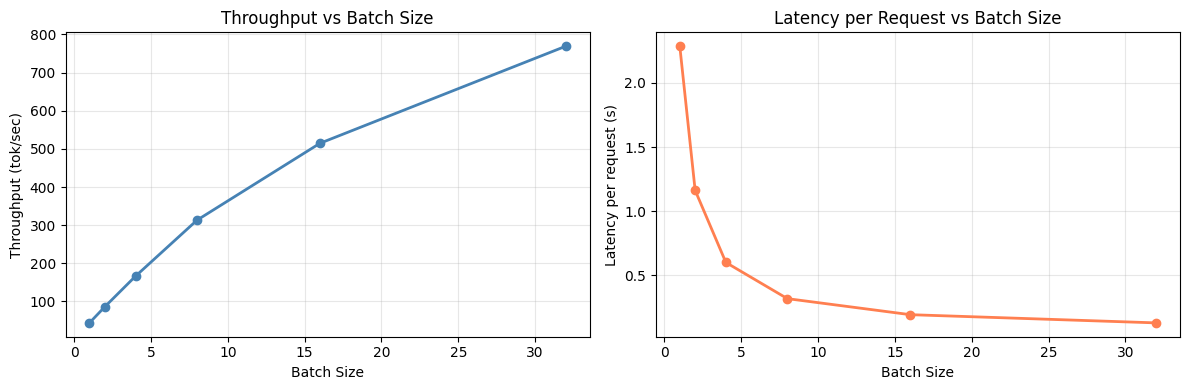

In [10]:
import matplotlib.pyplot as plt

batch_sizes  = [1, 2, 4, 8, 16, 32]
throughputs  = [43.7, 86.0, 166.3, 313.1, 514.7, 769.3]
latencies    = [2.287, 1.163, 0.601, 0.319, 0.194, 0.130]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# throughput
ax1.plot(batch_sizes, throughputs, 'o-', color='steelblue', linewidth=2)
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Throughput (tok/sec)")
ax1.set_title("Throughput vs Batch Size")
ax1.grid(True, alpha=0.3)

# latency
ax2.plot(batch_sizes, latencies, 'o-', color='coral', linewidth=2)
ax2.set_xlabel("Batch Size")
ax2.set_ylabel("Latency per request (s)")
ax2.set_title("Latency per Request vs Batch Size")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("batch_scaling.png", dpi=150)
plt.show()

In [11]:
# ── Test 3: KV cache effect — context length vs latency ───────────────────────
sampling_params = SamplingParams(temperature=0.7, max_tokens=50)

# prompts of increasing length
short_prompt = "What is machine learning?"

medium_prompt = """You are a financial analyst. A client asks you about machine learning.
They want to understand the basics, the applications in finance, and the key differences
between supervised and unsupervised approaches. Please explain machine learning."""

long_prompt = """You are a senior financial analyst at a major investment bank with 20 years
of experience. A new junior analyst has joined your team and wants to understand machine
learning from first principles. They have a strong background in statistics but no ML experience.
They specifically want to understand: what machine learning is, how it differs from traditional
statistical modeling, what supervised learning means, what unsupervised learning means,
what reinforcement learning means, how these are applied in quantitative finance,
what the key libraries are, and what they should study first.
Please give a comprehensive explanation suitable for someone with a statistics background."""

prompts = [
    ("short  (~10 tokens)",   short_prompt),
    ("medium (~50 tokens)",   medium_prompt),
    ("long   (~120 tokens)",  long_prompt),
]

print(f"{'Context':>25} {'Prompt tokens':>15} {'Time':>10} {'tok/sec':>10}")
print("-" * 65)

for label, prompt in prompts:
    # warmup
    _ = llm.generate([prompt], sampling_params)

    start = time.time()
    outputs = llm.generate([prompt], sampling_params)
    elapsed = time.time() - start

    prompt_tokens = len(outputs[0].prompt_token_ids)
    gen_tokens = len(outputs[0].outputs[0].token_ids)

    print(f"{label:>25} {prompt_tokens:>15} {elapsed:>9.3f}s {gen_tokens/elapsed:>9.1f}")

                  Context   Prompt tokens       Time    tok/sec
-----------------------------------------------------------------


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.24s/it, est. speed input: 4.03 toks/s, output: 40.27 toks/s]


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.16s/it, est. speed input: 4.32 toks/s, output: 43.15 toks/s]

...

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it, est. speed input: 104.12 toks/s, output: 42.33 toks/s]


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.18s/it, est. speed input: 104.18 toks/s, output: 42.35 toks/s]

     long   (~120 tokens)             123     1.198s      41.7
